# A.1.2 Teoretyczne Modele Semiwariogramu

## Spis Treści

1. Stworzenie sztucznego zbioru danych testowych.
2. Obliczenie eksperymentalnej semiwariancji.
3. Stworzenie modeli teoretycznych.
4. Zestawienie modeli.

## Wprowadzenie

Modelując semiwariancję wykorzystujemy do tego kilka modeli teoretycznych przedstawianych w literaturze. Najpopularniejsze są zaimplementowane w paczce `Pyinterpolate`. W tym samouczku porównamy je wszystkie. Nauczysz się:

- jak przygotować sztuczny obszar analizy w Pythonie,
- jakie modele teoretyczne są zaimplementowane w paczce,
- różnic między poszczególnymi modelami.

## Import paczek

In [1]:
from scipy.signal import convolve2d
from scipy.sparse import coo_matrix

from pyinterpolate import build_experimental_variogram
from pyinterpolate.variogram.theoretical.models import *

import matplotlib.pyplot as plt

## 1) Stworzenie sztucznego zbioru danych testowych

W pierwszym kroku stworzymy sztuczną powierzchnię analizy. Decydujemy się na to ponieważ możemy w ten sposób kontrolować parametry semiwariogramu i środek ciężkości ma być położony na porównanie semiwariogramów a nie analizę danych. Żeby nie było zbyt nudno, powierzchnia zostanie stworzona za pomocą [odwzorowania logistycznego](https://en.wikipedia.org/wiki/Logistic_map). Jest to odwzorowanie które dla pewnego zestawu parametrów wykazuje zachowanie chaotyczne (chaos stochastyczny).

**Odwzorowanie logistyczne** to funkcja rekurencyjna w postaci:

$$x_{n+1} = rx_{n}(1-x_{n}),$$

Gdzie;
- $x$: wartość odwzorowania dla kroków $n$ albo $n+1$. Wartość ta zależy tylko od poprzedniego kroku i parametrów początkowych i zawiera się w przedziale $x \in [0, 1]$.
- $r$: to specjalny parametr który wpływa na zachowanie układu. Ustawiony w granicach $[3.5, 4]$ doprowadza do chaotycznego zachowania systemu [więcej...](https://en.wikipedia.org/wiki/Logistic_map#Behavior_dependent_on_r).

Użyjemy funkcji `generate_logistic_map`, przyjmuje ona 3 parametry:

- `r`: ustawiony na **3.9**.
- `size`: długość wynikowej sekwencji. Powinna być stosunkowo duża, żeby wygodnie przetransformować ją na obraz. Ustawiona na **10 000** (co daje wynikową powierzchni o wielkości 100x100).
- `initial_ratio`: początkowe `x`, musi być między *0* a *1*. Ustawione na **0.33**.

In [2]:
# Odwzorowanie logistyczne

def generate_logistic_map(r: float, size: int, initial_ratio: float) -> np.array:
    # rxn(1-xn)
    vals = [initial_ratio]
    for _ in range(size-1):
        new_val = r * vals[-1] * (1 - vals[-1])
        vals.append(new_val)
    return np.array(vals)

In [3]:
values = generate_logistic_map(3.9, 10000, 0.33)

W tym momencie wygenerowaliśmy jednowymiarową tablicę, którą można przedstawić jako dyskretny sygnał.

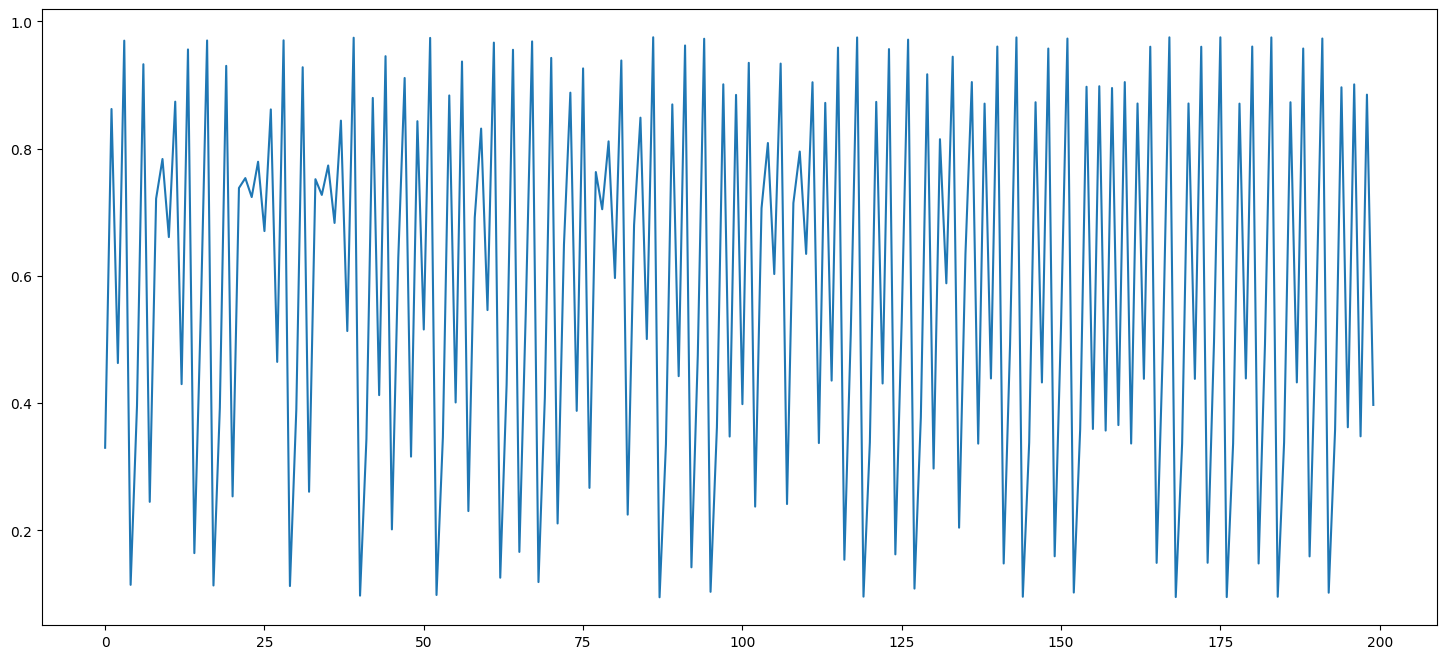

In [4]:
plt.figure(figsize=(18, 8))
# Ograniczamy liczbę wyników do początkowych 200 rekordów dla czytelności wykresu
plt.plot(values[0:200])
plt.show()

Przetransformujmy ten sygnał do dwuwymiarowej tablicy reprezentującej powierzchnię na planie kartezjańskim.

In [5]:
surface = np.reshape(values, (100, 100))

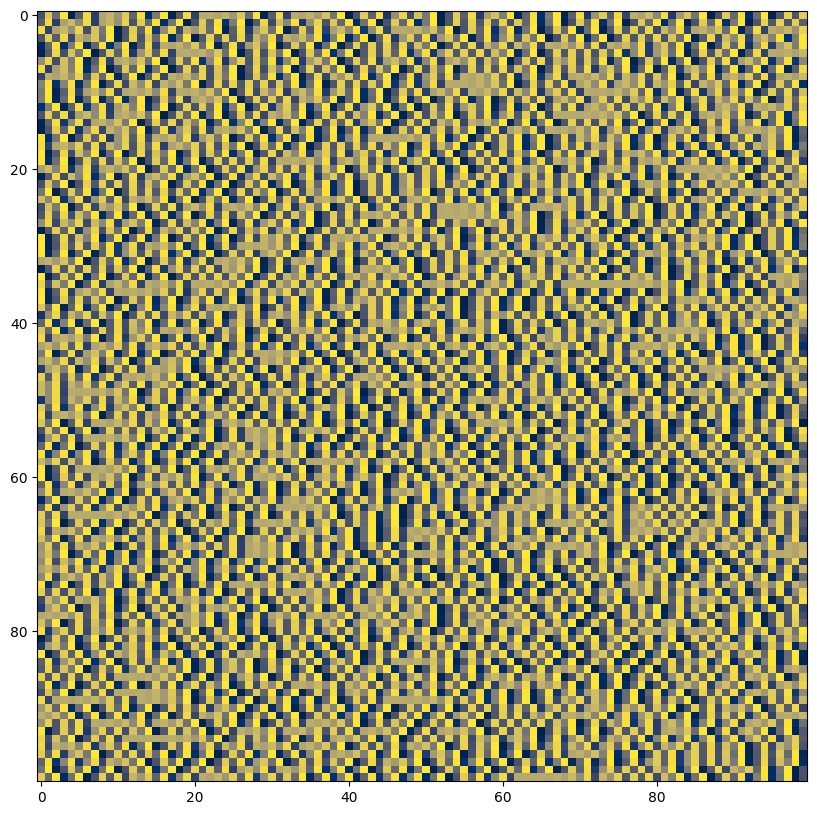

In [6]:
plt.figure(figsize=(10, 10))
plt.imshow(surface, cmap='cividis')
plt.show()

Aktualnie korelacja przestrzenna zbioru jest bardzo słaba, sąsiednie wartości nie są zbytnio powiązane. Można to zmienić używając operacji rozmycia - prostego filtru uśredniającego wartości w oknie o zadanym rozmiarze. Rozmiar tego okna będzie automatycznie parameterem `rang` (*range* - zasięg) semiwariogramu!

In [7]:
# Rozmycie

mean_filter = np.ones(shape=(7, 7))

surf_blurred = convolve2d(surface, mean_filter, boundary='wrap')

Sztuczna powierzchnia jest gotowa!

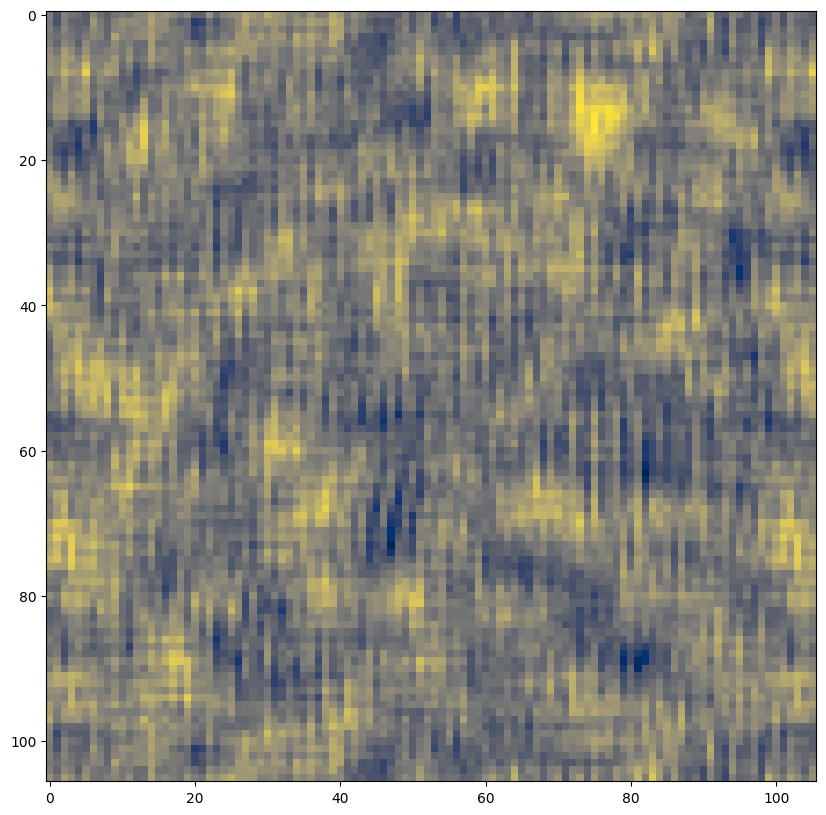

In [8]:
plt.figure(figsize=(10, 10))
plt.imshow(surf_blurred, cmap='cividis')
plt.show()

## 2) Obliczenie eksperymentalnej semiwariancji

Eksperymentalny semiwariogram wymaga przekształcenia tablicy w ciąg punktów:

```
[[współrzędna x1, współrzędna y1, wartość 1],
[współrzędna x2, współrzędna y2, wartość 2],
[...],]
```

Przekształcenie dwuwymiarowej tablicy przebiega w dwóch krokach. Pierwszy to stworzenie macierzy rzadkiej w `scipy`, a drugi to transformacja tej macierzy do wymaganej tablicy `numpy`.

In [11]:
# Transformacja x, y, wartość

In [12]:
sparse_data = coo_matrix(surf_blurred)

In [13]:
# data, col, row == value, x, y

In [14]:
xyval = np.asarray([sparse_data.col, sparse_data.row, sparse_data.data]).T

Efektywny zasięg korelacji wynosi siedem kroków, bo taki filtr uśredniający zastosowano wcześniej. Mając tę wiedzę ustawiamy `step_size` na dwie jednostki i `max_range` na 20 jednostek (znacznie więcej niż znane 7 kroków, ale chcemy sprawdzi jak zachowuje się wariogram na dalszych dystansach).

In [15]:
experimental = build_experimental_variogram(xyval, 2, 20)

In [16]:
semivars = experimental.experimental_semivariance_array.copy()

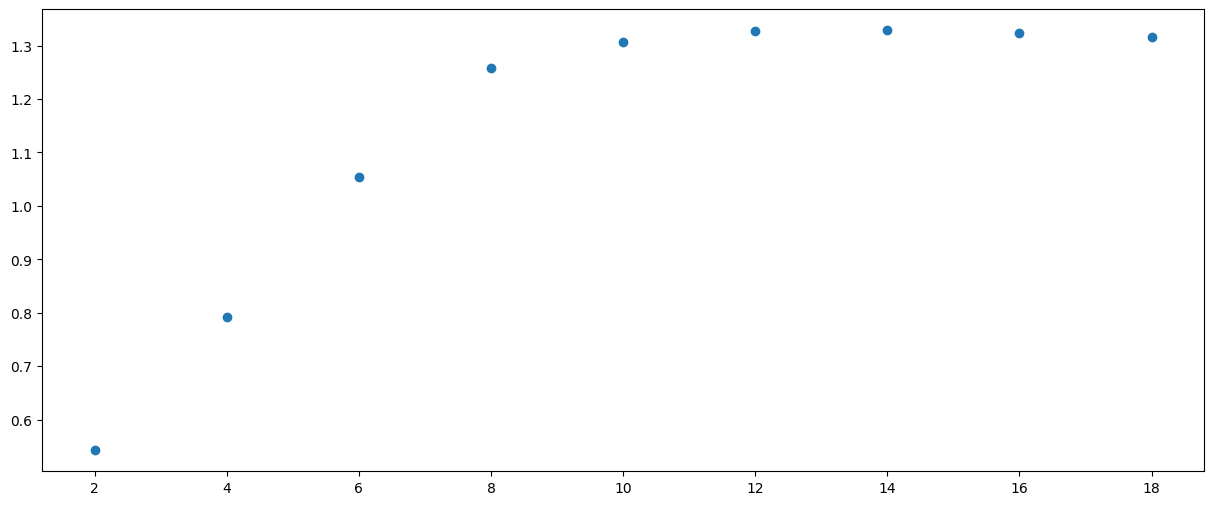

In [17]:
plt.figure(figsize=(15, 6))
plt.scatter(semivars[:, 0], semivars[:, 1])
plt.show()

Eksperymentalny semiwariogram wskazuje na:

- **nugget** na `0`,
- **sill** na `1.3`,
- **range** na `7`,
- a **lags** to lista kroków od 2 do 18 (o długości 2 jednostek).

Posiadając te parametry możemy modelowa każdy teoretyczny semiwariogram osobno, bez odwoływania się do klasy `TheoreticalVariogram`.

In [18]:
# Przygotuj nugget, sill, range i lagi

In [19]:
_nugget = 0
_sill = 1.3
_range = 7
_lags = semivars[:, 0].copy()

## 3) Stworzenie modeli teoretycznych

Modele wariogramu raczej nie są używane poza klasą `TheoreticalVariogram`, ale paczka pozwala na ich import. Lista modeli, które są aktualnie zaimplementowane to:

- circular,
- cubic,
- exponential,
- gaussian,
- linear,
- power,
- spherical.

Obliczamy semiwariogram dla każdej z tych funkcji korzystając z parametrów otrzymanych w poprzednim kroku.

In [20]:
circular = circular_model(lags=_lags,
                          nugget=_nugget,
                          sill=_sill,
                          rang=_range)

cubic = cubic_model(lags=_lags,
                    nugget=_nugget,
                    sill=_sill,
                    rang=_range)

exponential = exponential_model(lags=_lags,
                                nugget=_nugget,
                                sill=_sill,
                                rang=_range)

gaussian = gaussian_model(lags=_lags,
                          nugget=_nugget,
                          sill=_sill,
                          rang=_range)

linear = linear_model(lags=_lags,
                      nugget=_nugget,
                      sill=_sill,
                      rang=_range)

power = power_model(lags=_lags,
                    nugget=_nugget,
                    sill=_sill,
                    rang=_range)

spherical = spherical_model(lags=_lags,
                            nugget=_nugget,
                            sill=_sill,
                            rang=_range)

Sprawdzimy teraz każdy model osobno, możesz spróbować zgadnąć który z nich jest najlepszy przed porównaniem wszystkich na raz!

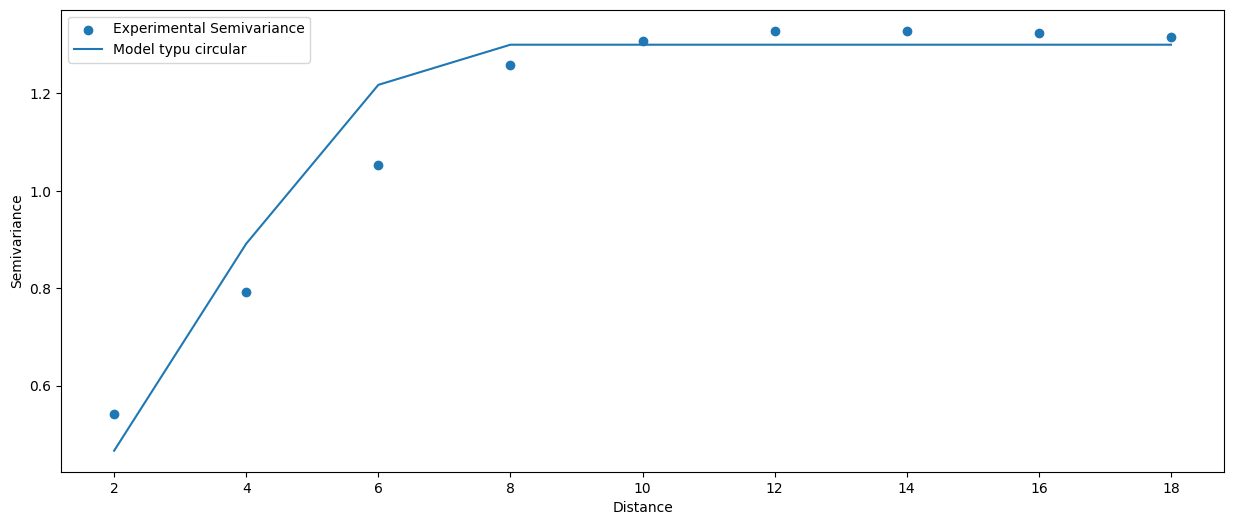

In [21]:
plt.figure(figsize=(15, 6))
plt.scatter(_lags, semivars[:, 1])
plt.plot(_lags, circular)
plt.legend(['Experimental Semivariance', 'Model typu circular'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

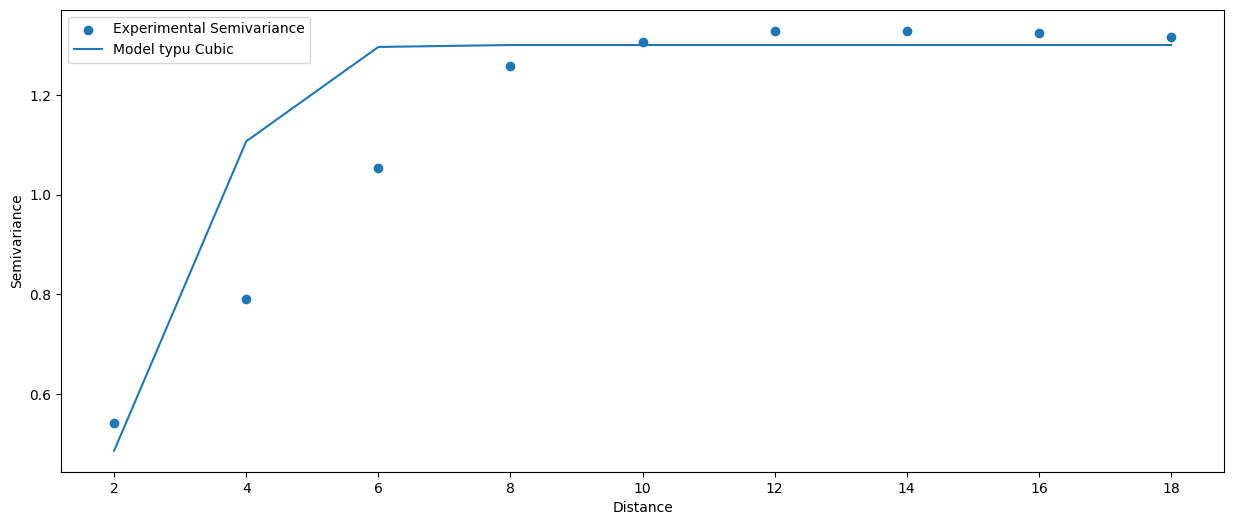

In [22]:
plt.figure(figsize=(15, 6))
plt.scatter(_lags, semivars[:, 1])
plt.plot(_lags, cubic)
plt.legend(['Experimental Semivariance', 'Model typu Cubic'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

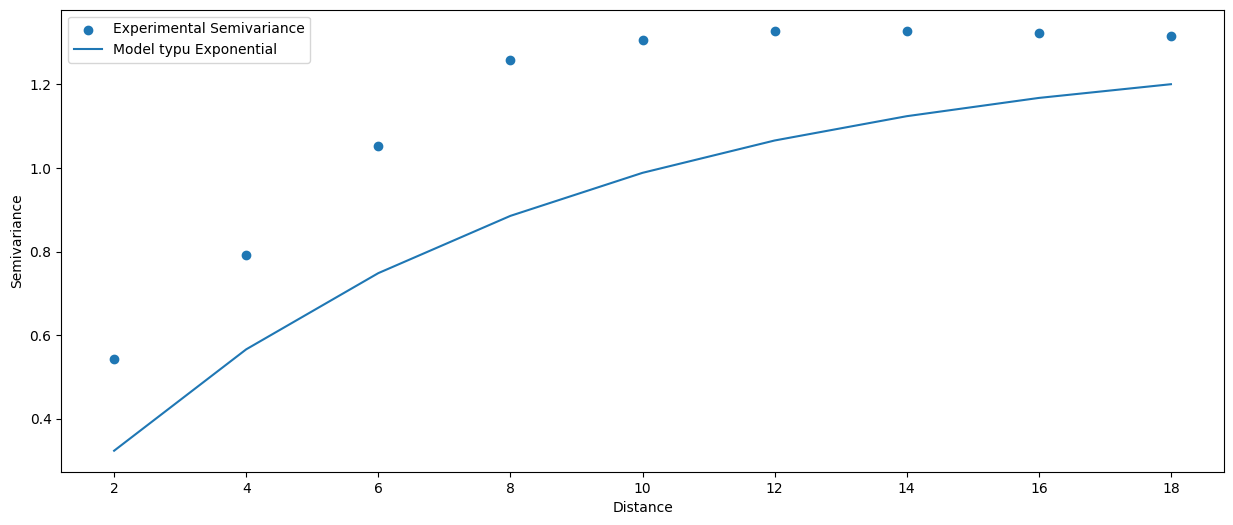

In [23]:
plt.figure(figsize=(15, 6))
plt.scatter(_lags, semivars[:, 1])
plt.plot(_lags, exponential)
plt.legend(['Experimental Semivariance', 'Model typu Exponential'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

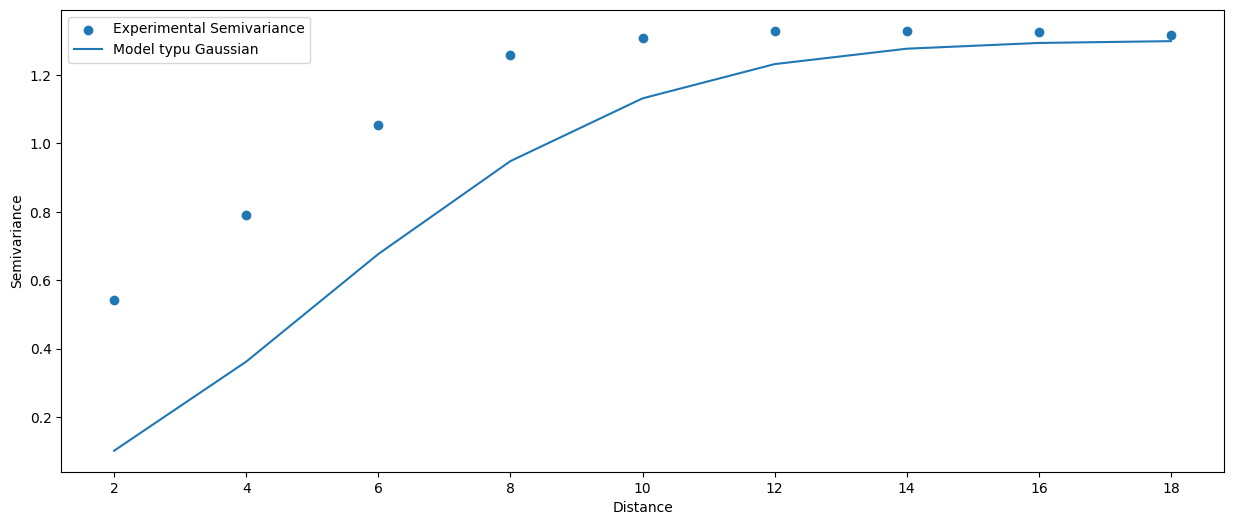

In [24]:
plt.figure(figsize=(15, 6))
plt.scatter(_lags, semivars[:, 1])
plt.plot(_lags, gaussian)
plt.legend(['Experimental Semivariance', 'Model typu Gaussian'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

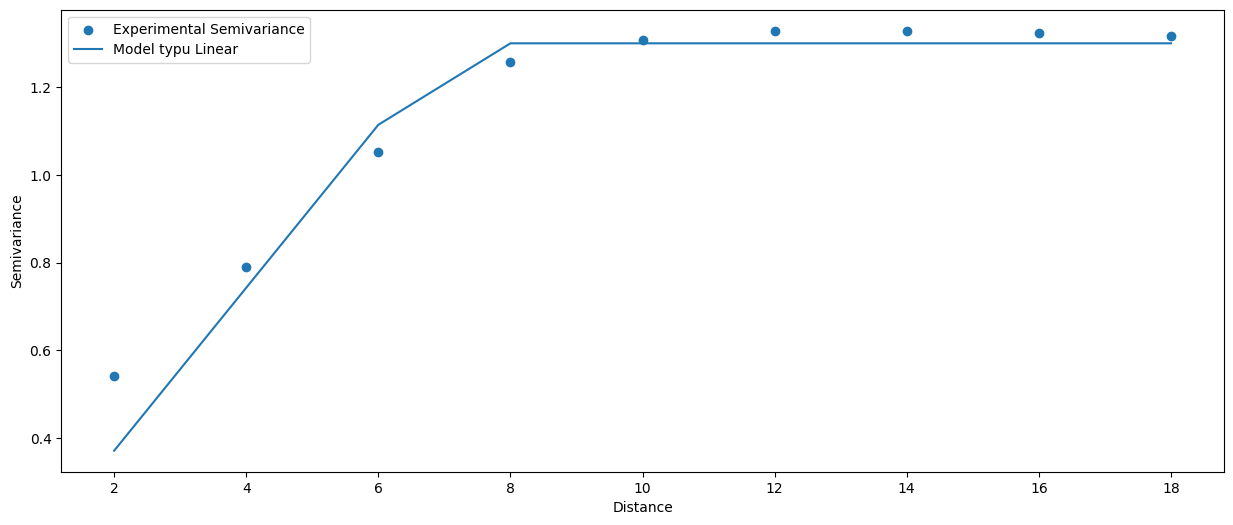

In [25]:
plt.figure(figsize=(15, 6))
plt.scatter(_lags, semivars[:, 1])
plt.plot(_lags, linear)
plt.legend(['Experimental Semivariance', 'Model typu Linear'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

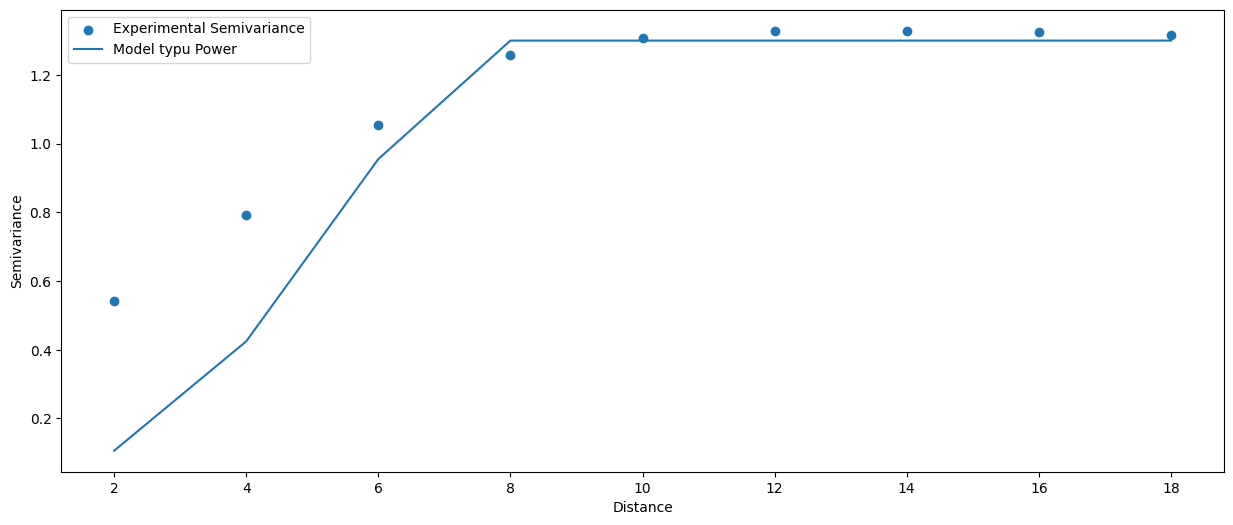

In [26]:
plt.figure(figsize=(15, 6))
plt.scatter(_lags, semivars[:, 1])
plt.plot(_lags, power)
plt.legend(['Experimental Semivariance', 'Model typu Power'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

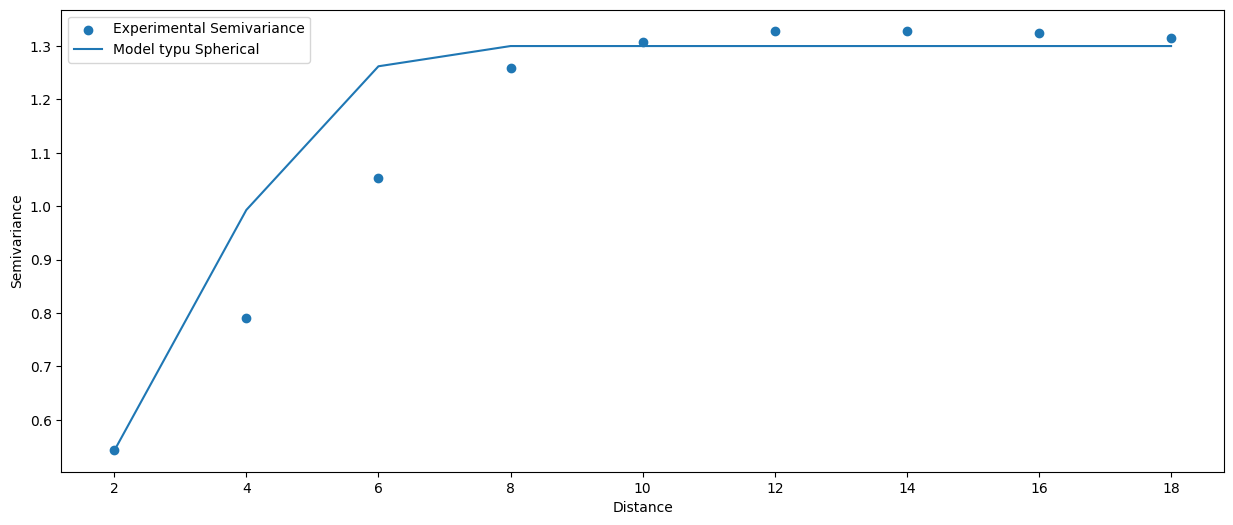

In [27]:
plt.figure(figsize=(15, 6))
plt.scatter(_lags, semivars[:, 1])
plt.plot(_lags, spherical)
plt.legend(['Experimental Semivariance', 'Model typu Spherical'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

Jak myślisz, który model teoretyczny jest najlepszy?

.
.
.

Prawdopodobnie wybrałeś modele typów `circular` albo `linear`! Generalnie najlepszy model to taki, który najlepiej odwzorowuje semiwariancję na bliskich dystansach i nie zawsze łatwo określić to "na oko". Tak samo wykorzystanie automatycznych metod może okazać się zwodnicze jeśli obliczają one błąd średniokwadratowy dla wszystkich punktów wariogramu - tych bliskich i tych dalszych. Zawsze warto zestawić kilka modeli na raz na jednym wykresie i podejmować decyzje oparte również na ludzkim osądzie.

## 4) Zestawienie wielu modeli


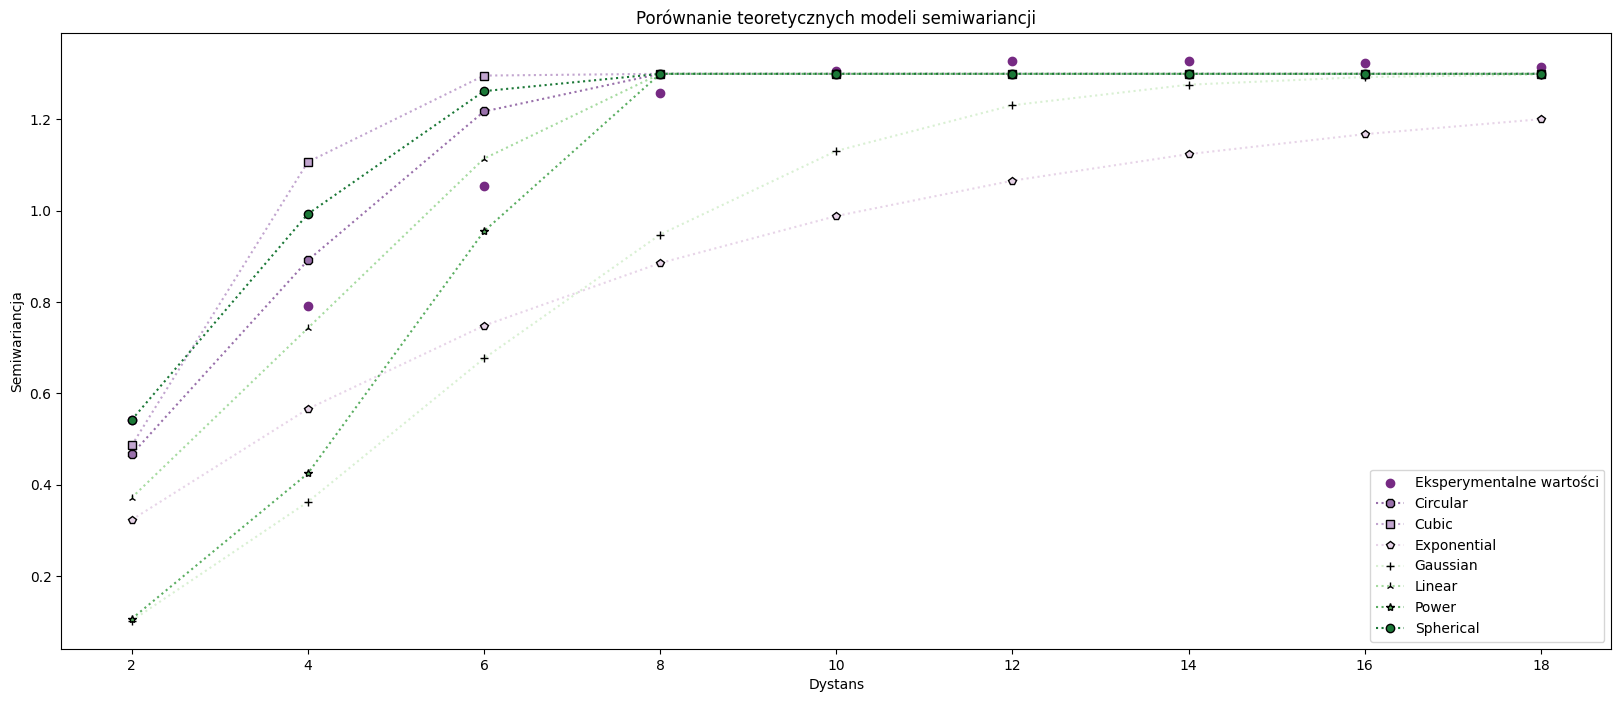

In [29]:
# Wykreśl wszystkie modele teoretyczne

plt.figure(figsize=(20, 8))
plt.scatter(_lags, semivars[:, 1], color='#762a83')
plt.plot(_lags, circular, ':8', color='#9970ab', mec='black')
plt.plot(_lags, cubic, ':s', color='#c2a5cf', mec='black')
plt.plot(_lags, exponential, ':p', color='#e7d4e8', mec='black')
plt.plot(_lags, gaussian, ':+', color='#d9f0d3', mec='black')
plt.plot(_lags, linear, ':2', color='#a6dba0', mec='black')
plt.plot(_lags, power, ':*', color='#5aae61', mec='black')
plt.plot(_lags, spherical, ':o', color='#1b7837', mec='black')
plt.title('Porównanie teoretycznych modeli semiwariancji')
plt.legend(['Eksperymentalne wartości',
            'Circular',
            'Cubic',
            'Exponential',
            'Gaussian',
            'Linear',
            'Power',
            'Spherical'])
plt.xlabel('Dystans')
plt.ylabel('Semiwariancja')
plt.show()

---

Kolejne kroki...

* A.1.3 Spatial Dependence Index
* A.2.1 Kierunkowy Semiwariogram
* A.2.2 Chmura semiwariancji
* A.2.3 klasy `ExperimentalVariogram` i `VariogramCloud`
* B.1.1 Ordinary i Simple Kriging

## Dziennik zmian

| Data       | Opis                                       | Autor |
|------------|--------------------------------------------|-------|
| 2024-03-30 | Pierwsza wersja samouczka w języku polskim | @SimonMolinsky |